In [1]:
from IPython.display import Image
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

# Models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    ExtraTreesClassifier,
    RandomForestRegressor,
    AdaBoostRegressor
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Model selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV , RandomizedSearchCV

# Metrics
from sklearn.metrics import (
    mean_squared_error,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    recall_score,
    confusion_matrix,
    precision_score,
    f1_score,
    classification_report,
    r2_score
)

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder , OneHotEncoder , PowerTransformer
from sklearn.impute import SimpleImputer

In [35]:
sns.set_palette(['#221f1f', '#b20710', '#e50914','#f5f5f1'])

In [36]:
df = pd.read_csv('netflix_titles.csv')

In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


In [38]:
for i in df.columns:
    null_rate = df[i].isna().sum() / len(df) * 100
    if null_rate > 0 :
        print("{} null rate: {}%".format(i,round(null_rate,2)))

director null rate: 29.91%
cast null rate: 9.37%
country null rate: 9.44%
date_added null rate: 0.11%
rating null rate: 0.05%
duration null rate: 0.03%


In [39]:
df['country'] = df['country'].fillna(df['country'].mode()[0])

df['cast'] = df['cast'].replace(np.nan, 'No Data')
df['director'] = df['director'].replace(np.nan, 'No Data')

df.dropna(inplace=True)

df.drop_duplicates(inplace= True)

In [40]:
df.isna().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [41]:
df['date_added'] = pd.to_datetime(df['date_added'],format='mixed')

df['month_date'] = df['date_added'].dt.month
df['month_name'] = df['date_added'].dt.month_name()
df['year_added'] = df['date_added'].dt.year
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_date,month_name,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No Data,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",9,September,2021
1,s2,TV Show,Blood & Water,No Data,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",9,September,2021
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,9,September,2021
3,s4,TV Show,Jailbirds New Orleans,No Data,No Data,United States,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",9,September,2021
4,s5,TV Show,Kota Factory,No Data,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,9,September,2021


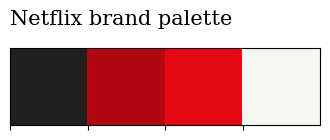

In [42]:
sns.palplot(['#221f1f', '#b20710', '#e50914','#f5f5f1'])
plt.title("Netflix brand palette ",loc='left',fontfamily='serif',fontsize=15,y=1.2)
plt.show()

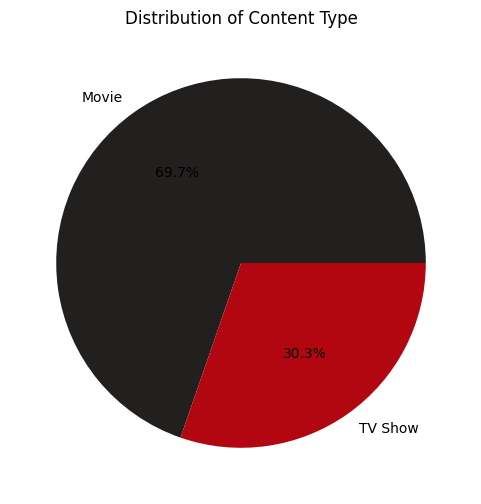

In [43]:
newDf = df.groupby(['type'])['type'].count()

plt.figure(figsize=(6,6))

plt.pie(
    newDf,
    labels=newDf.index,
    autopct='%1.1f%%'
)

plt.title("Distribution of Content Type")
plt.show()

# Countries with the most Netflix Shows

In [49]:
df['first_country'] = df['country'].apply(lambda x : x.split(',')[0])
df['first_country'] = df['first_country'].replace('United States', 'USA')
df['first_country'] = df['first_country'].replace('United Kingdom', 'UK')
df['first_country'] = df['first_country'].replace('South Korea', 'S. Korea')

  first_country  type
0           USA  4031
1         India  1008
2            UK   627
3        Canada   271
4         Japan   257
5        France   212
6      S. Korea   211
7         Spain   181
8        Mexico   134
9     Australia   115


<Axes: xlabel='first_country', ylabel='type'>

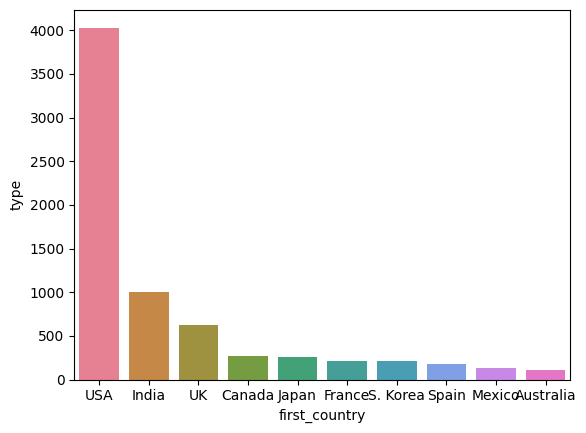

In [ ]:
tv_counts = df.groupby('first_country')['type'].count().sort_values(ascending=False).reset_index()[:10]

print(tv_counts)

sns.barplot(
    x='first_country',
    data=tv_counts,
    y='type',
    hue='first_country'
)

In [ ]:
data_q2q3 = df[['type', 'first_country']].groupby('first_country')['type'].value_counts().sort_values,ascending=False).unstack()


TypeError: 'str' object is not callable

# Rating Stuff

In [ ]:
ratings_ages = {
    'TV-PG': 'Older Kids',
    'TV-MA': 'Adults',
    'TV-Y7-FV': 'Older Kids',
    'TV-Y7': 'Older Kids',
    'TV-14': 'Teens',
    'R': 'Adults',
    'TV-Y': 'Kids',
    'NR': 'Adults',
    'PG-13': 'Teens',
    'TV-G': 'Kids',
    'PG': 'Older Kids',
    'G': 'Kids',
    'UR': 'Adults',
    'NC-17': 'Adults'
}

df['target_ages'] = df['rating'].replace(ratings_ages)
df['target_ages'].unique()

df['genre'] = df['listed_in'].apply(lambda x :  x.replace(' ,',',').replace(', ',',').split(','))

0                                      [Documentaries]
1    [International TV Shows, TV Dramas, TV Mysteries]
2    [Crime TV Shows, International TV Shows, TV Ac...
3                             [Docuseries, Reality TV]
4    [International TV Shows, Romantic TV Shows, TV...
Name: genre, dtype: object
0     Teens
1    Adults
2    Adults
3    Adults
4    Adults
Name: target_ages, dtype: str
